<a href="https://colab.research.google.com/github/kruthika1706/java/blob/main/557.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         Date  Location  Temperature   Humidity  Wind Speed  Precipitation  \
0  2024-01-01  New York    87.524795  75.655455   28.379506       0.000000   
1  2024-01-02  New York    83.259325  28.712617   12.436433       0.526995   
2  2024-01-03  New York    80.943050  64.740043   14.184831       0.916884   
3  2024-01-04  New York    78.097552  59.738984   19.444029       0.094134   
4  2024-01-05  New York    37.059963  34.766784    3.689661       1.361272   

   Cloud Cover     Pressure  Rain Tomorrow  
0    69.617966  1026.030278              0  
1    41.606048   995.962065              0  
2    77.364763   980.796739              1  
3    52.541196   979.012163              0  
4    85.584000  1031.790859              0  


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


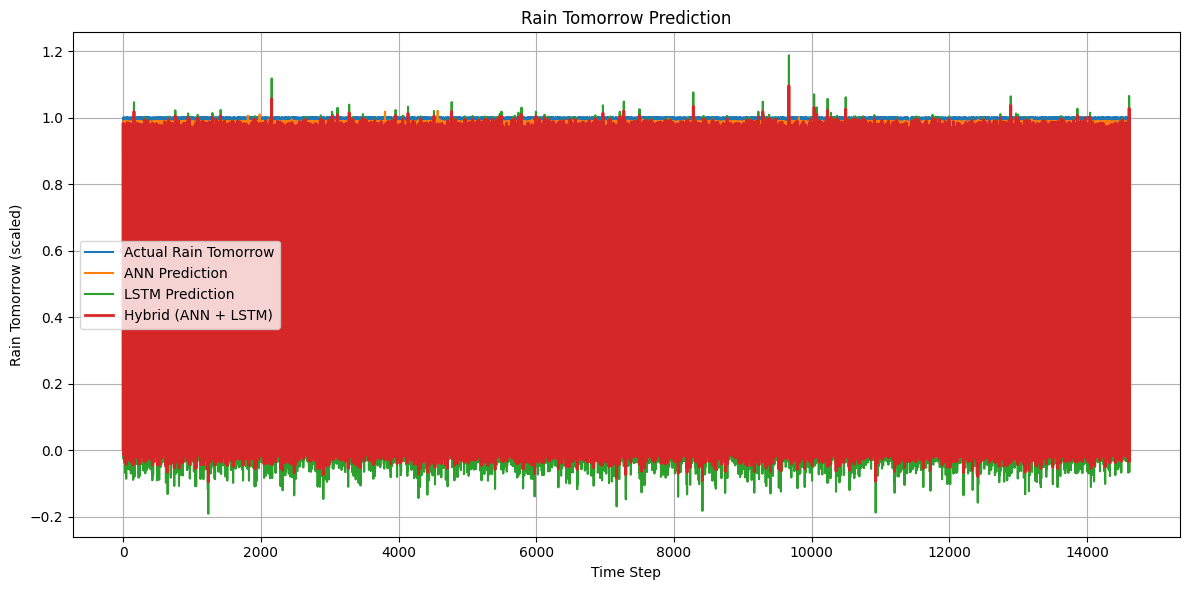

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# ✅ Correct file path (removed single quotes from the file name)
file_path = r"C:\Users\kruth\OneDrive\Desktop\your_rainfall_data.csv"

# Load your dataset
df = pd.read_csv("/content/'your_rainfall_data.csv'.csv")

# Check the first few rows to inspect your dataset
print(df.head())

# Feature selection (ignoring 'Date' and 'Location' for simplicity)
features = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover', 'Pressure']
target = 'Rain Tomorrow'

# Extract features and target variable
X = df[features].values
y = df[target].values

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets (80% training, 20% testing)
train_size = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape X for LSTM (samples, timesteps, features) - LSTM expects 3D input
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Build and train the ANN model
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])
ann_model.compile(optimizer='adam', loss='mse')
ann_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

# Build and train the LSTM model
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=16, verbose=0)

# Make predictions using both models
pred_ann = ann_model.predict(X_test)
pred_lstm = lstm_model.predict(X_test_lstm)

# Hybrid model = average of ANN and LSTM predictions
pred_hybrid = (pred_ann + pred_lstm) / 2

# ⚠️ Note: MinMaxScaler was only applied to features (X), not y.
# If you want to inverse transform y, you'd need to scale it first and use a separate scaler.
# So instead, we'll plot in scaled space for fair comparison.
# Or you can remove the inverse function if it's not meaningful.

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Rain Tomorrow')
plt.plot(pred_ann.flatten(), label='ANN Prediction')
plt.plot(pred_lstm.flatten(), label='LSTM Prediction')
plt.plot(pred_hybrid.flatten(), label='Hybrid (ANN + LSTM)', linewidth=2)
plt.title("Rain Tomorrow Prediction")
plt.xlabel("Time Step")
plt.ylabel("Rain Tomorrow (scaled)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()